# Notebook 4: fine-tuning

M/EEG foundation models workshop · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/notebooks/04_fm_finetune.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Setup</div><div style="font-size:0.85em; color:#5B6472;">check · install · download</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Meet the data</div><div style="font-size:0.85em; color:#5B6472;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Classical baselines</div><div style="font-size:0.85em; color:#5B6472;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Frozen REVE</div><div style="font-size:0.85em; color:#5B6472;">embeddings · linear probe · few labels</div></td><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Fine-tuning</div><div style="font-size:0.85em; color:#C9D6E8;">demo · GPU optional</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Who won?</div><div style="font-size:0.85em; color:#5B6472;">one table · per person · statistics</div></td></tr></table>

In notebook 3 the weights of REVE stayed frozen, and a linear probe on its embeddings scored below the classical decoders. This notebook lets the weights change: **fine-tuning**. It explains how a neural network learns, runs a few learning steps by hand, then looks at a full fine-tuning run and at its scores on day 2.

Fine-tuning 69 million weights takes about 5 minutes on a GPU and much longer on a laptop processor. So the run was done in advance and its results ship with the tutorial package. With a GPU you can redo it here by setting `RUN_FINETUNE = True`.

| Part | Content |
|---|---|
| 1 | From a frozen model to a fine-tuned one |
| 2 | How a network learns |
| 3 | A full fine-tuning run |
| 4 | Scores on day 2 |
| 5 | What changed inside the model |
| 6 | One participant alone, and fewer labels |
| 7 | What it costs |
| 8 | Go further (optional) |
| 9 | Summary |

<div style="color:#1F2937; background:#F9FAFB; border:1px solid #E5E7EB; border-radius:6px; padding:8px 14px;"><b>Three kinds of blocks</b><div style="margin:3px 0;"><span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> &nbsp;the code is complete: run the cell and read the comments.</div><div style="margin:3px 0;"><span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> &nbsp;complete the one or two lines marked <code>&lt;---</code>.</div><div style="margin:3px 0;"><span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> &nbsp;optional: write the cell yourself, from hints and links to the documentation.</div><div style="font-size:0.9em; color:#5B6472; margin-top:4px;">Each exercise is followed by a folded solution. Run the solution before moving on: the next cells use its variables. Type 3 blocks can wait until after the session.</div></div>

In [1]:
# ---- Install (Colab only), imports and data folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"   # the tutorial repository
USE_DRIVE = True                                     # Colab: read the data that notebook 0 saved in your Google Drive

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import meeg_fm as mf                     # the tutorial package: data helpers, REVE, saved results
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.facecolor": "white",
                     "legend.frameon": False})
DATA_DIR = mf.use_data_dir()                         # the folder notebook 0 filled
RESULTS_DIR = (DATA_DIR if IN_COLAB else Path(".")) / "results"      # where the scores of every notebook are saved
RESULTS_DIR.mkdir(exist_ok=True)
DEVICE = mf.pick_device()                            # "cuda" (NVIDIA GPU), "mps" (Apple GPU) or "cpu"
print("Data folder:", DATA_DIR, "| device:", DEVICE)

Data folder: ~/mne_data | device: mps


In [2]:
# ---- Parameters
SUBJECTS = list(range(1, 10))                # the saved results use the 9 participants
RUN_FINETUNE = False                         # True: fine-tune here (about 5 min on a GPU); False: read the saved run
RECIPE = dict(head_epochs=3, epochs=10,      # passes over the training trials: head alone, then every weight
              head_lr=1e-4, lr=3e-5,         # learning rate of each stage
              batch_size=32)                 # trials per learning step
HANDS = {"left_hand": "#1baf7a", "right_hand": "#4a3aa7"}
COLORS = {"CSP + LDA": "#0B5CAD", "Tangent space + LR": "#E8710A", "REVE frozen + LR": "#7C3AED",
          "REVE fine-tuned": "#BE185D"}

## 1. From a frozen model to a fine-tuned one

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Fine-tuning continues the training of the pretrained model on our labelled trials: the head first, then every weight.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: why it matters</b><br>The frozen result says what the model knows without help. In practice a pretrained model is almost always adapted to the task, and the scores published for foundation models are fine-tuned scores. Notebook 3 alone would be an unfair test of REVE.</div>

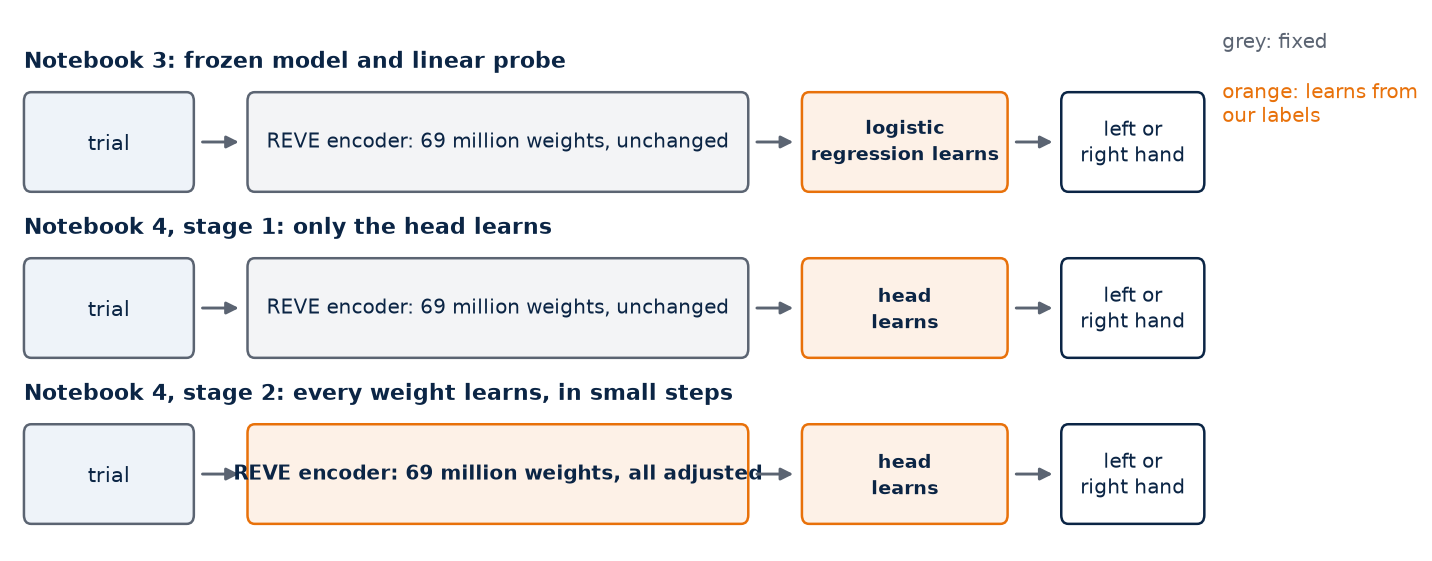

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: encoder, head, fine-tuning</b><br>REVE has two parts. The <b>encoder</b> is the pretrained transformer that turns a trial into tokens: almost all of the 69 million weights. The <b>head</b> is a small layer added on top that turns the tokens into an answer, left or right. The head is new: its weights start at random and have to be learned from our labels.<br>In notebook 3 the encoder was frozen and a logistic regression played the role of the head. <b>Fine-tuning</b> continues the training of the encoder itself on our task, starting from the pretrained weights, so that the embeddings change to suit left against right hand.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: head first, then everything</b><br>We fine-tune in <b>two stages</b>, a common practice with pretrained models (Kumar et al., 2022). First only the head learns, with the encoder frozen: this is a linear probe trained inside the network. Then every weight learns, in small steps. If we skipped the first stage, the random head would send large and meaningless corrections into the encoder and damage what pretraining built.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The trials and the split

One difference with notebooks 2 and 3: we train **one model on the day 1 of all participants together**, 1,296 trials, and test it on each participant's day 2. Notebook 3 showed that REVE gains from seeing several people, and 144 trials are few for 69 million weights (part 6 tries it). We also set aside 15 % of the day-1 trials, the **held-out** trials: the model never learns from them, and we use them to follow the training.

In [3]:
# ---- Every trial prepared for REVE (200 Hz, 0.5-99.5 Hz), and three sets: fit, held-out, test
X, y, meta = mf.load_epochs(SUBJECTS, sfreq=200, fmin=0.5, fmax=99.5)
subject = meta["subject"].to_numpy()
train = (meta["session"] == "0train").to_numpy()     # day 1
test = (meta["session"] == "1test").to_numpy()       # day 2

groups = [f"{s}-{c}" for s, c in zip(subject[train], y[train])]      # keep every participant and hand in both sets
fit, held_out = train_test_split(np.flatnonzero(train), test_size=0.15, stratify=groups, random_state=0)
print("X:", X.shape, "(trials, channels, samples)")
print(f"{len(fit)} day-1 trials to learn from, {len(held_out)} day-1 trials held out, {test.sum()} day-2 trials to test on")

X: (2592, 22, 800) (trials, channels, samples)
1101 day-1 trials to learn from, 195 day-1 trials held out, 1296 day-2 trials to test on


## 2. How a network learns

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>A network learns by repeating one small step: measure the error on a few trials, and move every weight a little in the direction that reduces it.</div>

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: loss, gradient, learning rate</b><br>For each trial the network outputs a probability for <i>left</i> and for <i>right</i>. The <b>loss</b> measures how wrong it is: here the <b>cross-entropy</b>, which is 0 when the network gives probability 1 to the correct hand, 0.69 when it says 50/50, and grows without limit when it is confident and wrong.<br>Learning means changing the weights so that the loss goes down. For every weight, the computer works out in which direction a small change would lower the loss: this is the <b>gradient</b>, obtained by <b>backpropagation</b>. An <b>optimiser</b> then moves every weight a little in that direction. The size of the move is the <b>learning rate</b>.</div>

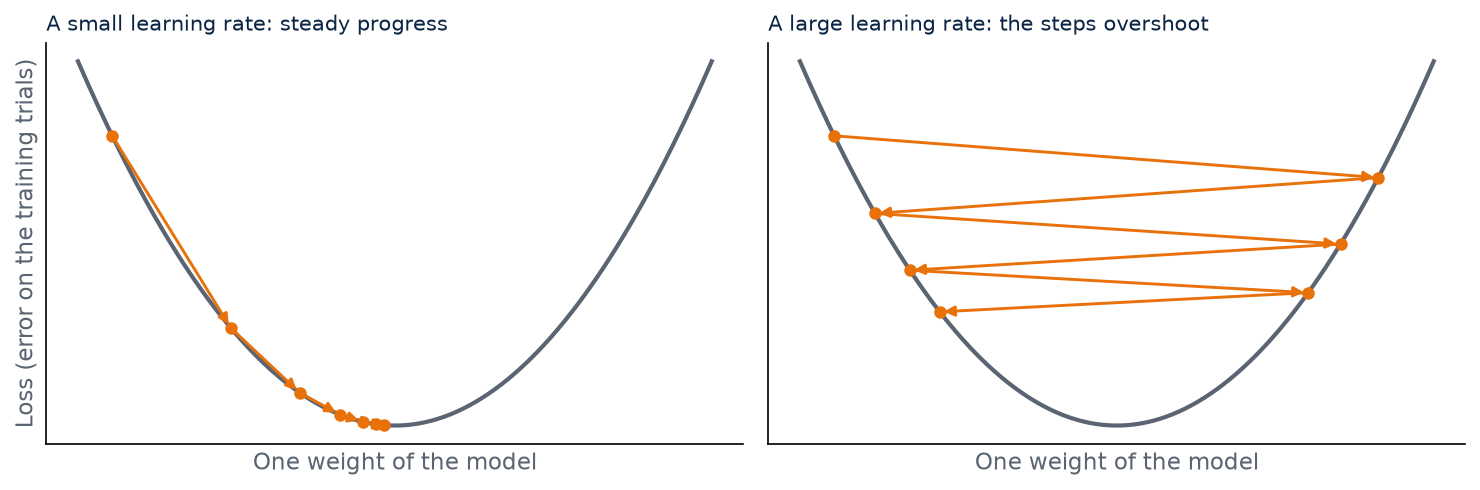

<div style="border-left:5px solid #0B5CAD; background:#EEF3F9; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B5CAD;">Concept: batch, step, pass</b><br>The gradient is computed on a small group of trials at a time, a <b>batch</b> (here 32 trials), and the weights move after each batch: one <b>step</b>. One pass over all the training trials is called an <b>epoch</b>; we will say <b>pass</b>. A run is a few passes: 13 here, about 450 steps.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Load REVE with a head

In [4]:
# ---- The pretrained model, with its new head
model = mf.load_reve(mf.CHANNELS, X.shape[-1])                       # encoder: pretrained; head: random
positions = model.get_positions(mf.CHANNELS)                         # x, y, z of each electrode

parts = {name: sum(p.numel() for p in part.parameters()) for name, part in model.named_children()}
head_weights = parts["final_layer"]
print(f"Encoder: {(sum(parts.values()) - head_weights) / 1e6:.1f} million weights")
print(f"Head:    {head_weights / 1e6:.2f} million weights")
print(model.final_layer)

Encoder: 69.2 million weights
Head:    0.18 million weights
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): LayerNorm((45056,), eps=1e-05, elementwise_affine=True, bias=True)
  (2): Linear(in_features=45056, out_features=2, bias=True)
)


The head flattens the 88 tokens of a trial (88 × 512 = 45,056 numbers) and maps them to 2 outputs, one per hand.

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Freeze the encoder

In PyTorch every weight has a switch, `requires_grad`: when it is `False` the weight does not learn. Switch off every weight outside the head, then count the weights that still learn.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>model.named_parameters()</code> gives pairs (name, weight). The names of the head's weights start with <code>&quot;final_layer&quot;</code>. For a weight <code>p</code>: <code>p.requires_grad = False</code>, and <code>p.numel()</code> is how many numbers it holds.</div>

In [5]:
# ---- Exercise: freeze the encoder, count what still learns
for name, p in model.named_parameters():
    if not name.startswith("final_layer"):
        ...                                          # <--- switch this weight off
learning = ...                                       # <--- total size of the weights whose requires_grad is True

In [6]:
#@title Solution (try first)
# ---- Freeze the encoder, count what still learns
for name, p in model.named_parameters():
    if not name.startswith("final_layer"):
        p.requires_grad = False
learning = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{learning:,} weights learn (the head); {sum(parts.values()) - learning:,} are frozen")

180,226 weights learn (the head); 69,189,120 are frozen


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> A few learning steps, by hand

One batch of 32 trials and four steps on the head, at two learning rates. The five numbered lines are the whole training loop of deep learning; a full run repeats them a few hundred times on different batches.

In [7]:
# ---- Four steps on one batch: answer, loss, gradient, move the weights
rows = fit[:32]                                                      # one batch
x_batch = torch.from_numpy(mf.reve.normalize(X[rows]))               # z-score each channel of each trial
target = torch.tensor([mf.CLASSES.index(c) for c in y[rows]])        # 0 = left hand, 1 = right hand
pos_batch = positions.expand(len(rows), -1, -1)
random_head = {name: value.clone() for name, value in model.final_layer.state_dict().items()}
model.eval()                                                         # no random dropout: the same input gives the same output


def four_steps(learning_rate):
    """Loss on the batch before each of four steps on the head, starting from the same random head."""
    model.final_layer.load_state_dict(random_head)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=learning_rate)
    losses = []
    for _ in range(4):
        output = model(x_batch, pos=pos_batch)                       # 1. the network's answer for each trial
        loss = torch.nn.functional.cross_entropy(output, target)     # 2. how wrong it is
        optimizer.zero_grad()
        loss.backward()                                              # 3. the gradient of the loss for every weight that learns
        optimizer.step()                                             # 4. move those weights a little
        losses.append(round(loss.item(), 3))                         # 5. keep the loss, and start again
    return losses


print("Guessing gives a loss of 0.693.")
print("Learning rate 0.00001:", four_steps(1e-5))
print("Learning rate 0.0001: ", four_steps(1e-4))

Guessing gives a loss of 0.693.


Learning rate 0.00001: [0.707, 0.683, 0.67, 0.66]


Learning rate 0.0001:  [0.707, 1.009, 0.56, 0.597]


The head starts at random, so the first loss is that of a network that guesses, or a little worse. With the small learning rate the loss goes down at every step. With a rate ten times larger the first step overshoots and the loss goes up before it comes down, as in the right panel of the figure above. These four steps used the same 32 trials each time; real training changes batch at every step, so that the network cannot learn one batch by heart.

## 3. A full fine-tuning run

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>The run takes about five minutes on a GPU. Its accuracy on held-out day-1 trials tells whether it worked, without touching day 2.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Run it, or read the saved run

`mf.finetune_reve` repeats the step above over every batch and every pass, in the two stages of part 1, and after each pass measures the accuracy on the held-out trials. With `RUN_FINETUNE = False` we read the table saved by the same function (`meeg_fm/precompute_finetune.py`, run on an Apple GPU).

In [8]:
# ---- Fine-tune REVE on the day 1 of all participants, or read the saved run
if RUN_FINETUNE:
    finetuned, history = mf.finetune_reve(X[fit], y[fit], X[held_out], y[held_out], device=DEVICE, **RECIPE)
    history = pd.DataFrame(history)
    p_right = mf.predict_proba(finetuned, X[test])[:, mf.CLASSES.index("right_hand")]
    predictions = pd.DataFrame({"subject": subject[test], "label": y[test], "p_right": p_right})
else:
    saved_history, saved_predictions = mf.load_precomputed("history"), mf.load_precomputed("predictions")
    history = saved_history[(saved_history["run"] == "all participants") & (saved_history["seed"] == 0)]
    predictions = saved_predictions[(saved_predictions["run"] == "all participants") & (saved_predictions["seed"] == 0)]
history[["epoch", "stage", "loss", "train_accuracy", "eval_accuracy", "seconds"]].round(2)

,epoch,stage,loss,train_accuracy,eval_accuracy,seconds
0,1,head only,0.74,0.53,0.61,8.98
1,2,head only,0.60,0.65,0.52,16.49
2,3,head only,0.51,0.78,0.67,23.96
3,4,all weights,0.41,0.86,0.78,49.76
4,5,all weights,0.15,0.96,0.82,75.01
5,6,all weights,0.03,1.00,0.86,100.31
6,7,all weights,0.01,1.00,0.86,125.53
7,8,all weights,0.00,1.00,0.86,150.96
8,9,all weights,0.00,1.00,0.86,176.54
9,10,all weights,0.00,1.00,0.86,202.44


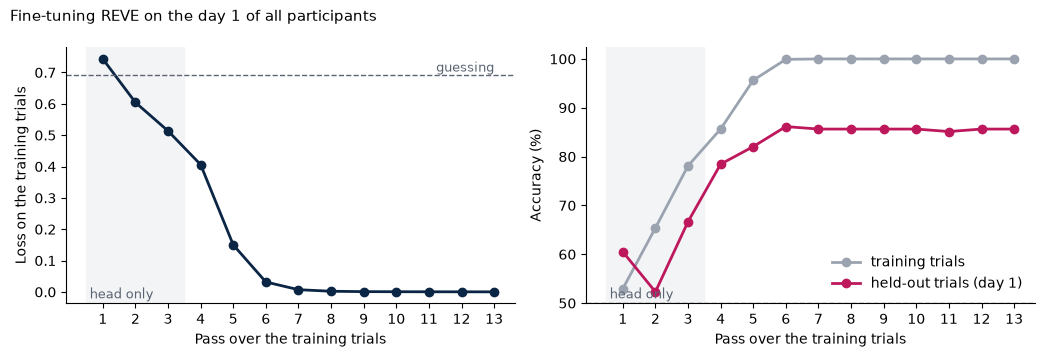

In [9]:
# ---- Loss and accuracy after each pass
def plot_history(history, title):
    """Loss on the training trials, and accuracy on the training and held-out trials, pass by pass."""
    fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6))
    passes = history["epoch"]
    axes[0].plot(passes, history["loss"], color="#0B2545", marker="o", lw=2)
    axes[0].axhline(np.log(2), color="#5B6472", lw=1, ls="--")
    axes[0].text(passes.max(), np.log(2), "guessing", color="#5B6472", fontsize=9, va="bottom", ha="right")
    axes[0].set_ylabel("Loss on the training trials")
    axes[1].plot(passes, 100 * history["train_accuracy"], color="#9AA3AF", marker="o", lw=2, label="training trials")
    axes[1].plot(passes, 100 * history["eval_accuracy"], color="#BE185D", marker="o", lw=2, label="held-out trials (day 1)")
    axes[1].axhline(50, color="#5B6472", lw=1, ls="--")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].legend(loc="lower right")
    n_head = (history["stage"] == "head only").sum()
    for ax in axes:
        if n_head:
            ax.axvspan(0.5, n_head + 0.5, color="#F3F4F6", zorder=0)
            ax.text(0.6, 0.02, "head only", transform=ax.get_xaxis_transform(), color="#5B6472", fontsize=9)
        ax.set_xlabel("Pass over the training trials")
        ax.set_xticks(passes)
    fig.suptitle(title, x=0.01, ha="left", fontsize=11)
    plt.tight_layout()
    plt.show()


plot_history(history, "Fine-tuning REVE on the day 1 of all participants")

In the saved run, the head alone (grey area) brings the held-out accuracy to 67 %. When every weight learns, the loss falls to almost 0 within three passes and the model gets every training trial right, while the held-out accuracy settles at 86 %. The gap between the two curves is overfitting; the held-out curve is the one to read. We fixed the number of passes before the run.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Does it work every time?

A fine-tuning run involves chance: the head starts from random weights and the batches are drawn in a random order. A **random seed** is the number that fixes these draws. The package holds the same run repeated with four seeds, for our two-stage recipe and for a simpler one: a single stage where every weight learns from the start, with a learning rate about three times larger (0.0001).

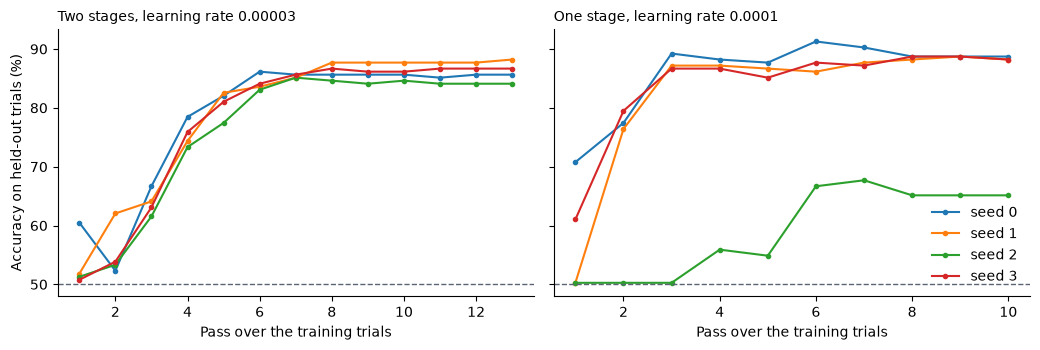

,0,1,2,3
"mean balanced accuracy on day 2 (%), by seed",,,,
"One stage, learning rate 0.0001",87.2,87.0,65.4,86.0
"Two stages, learning rate 0.00003",85.0,85.2,84.6,84.6


In [10]:
# ---- Held-out accuracy of four runs of each recipe, and their mean score on day 2
saved_history, saved_predictions = mf.load_precomputed("history"), mf.load_precomputed("predictions")


def day2_scores(rows):
    """Balanced accuracy on day 2 of each participant, from a table of predictions."""
    return rows.groupby("subject").apply(
        lambda r: balanced_accuracy_score(r["label"], np.where(r["p_right"] > 0.5, "right_hand", "left_hand")),
        include_groups=False)


RECIPES = {"all participants": "Two stages, learning rate 0.00003", "all participants, one stage": "One stage, learning rate 0.0001"}
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.6), sharey=True)
by_seed = {}
for ax, (run, title) in zip(axes, RECIPES.items()):
    for seed, rows in saved_history[saved_history["run"] == run].groupby("seed"):
        ax.plot(rows["epoch"], 100 * rows["eval_accuracy"], marker="o", ms=3, lw=1.5, label=f"seed {seed}")
        chosen = (saved_predictions["run"] == run) & (saved_predictions["seed"] == seed)
        by_seed[title, seed] = 100 * day2_scores(saved_predictions[chosen]).mean()
    ax.axhline(50, color="#5B6472", lw=1, ls="--")
    ax.set_xlabel("Pass over the training trials")
    ax.set_title(title, loc="left", fontsize=10)
axes[0].set_ylabel("Accuracy on held-out trials (%)")
axes[1].legend()
plt.tight_layout()
plt.show()
pd.Series(by_seed).unstack().round(1).rename_axis("mean balanced accuracy on day 2 (%), by seed")

<div style="border-left:5px solid #4A3AA7; background:#F1EFFB; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#4A3AA7;">What we see</b><br>The two-stage recipe gives nearly the same result four times: 84.6 to 85.2 % on day 2. The one-stage recipe does a little better three times (86 to 87 %) and fails once, at 65 %. Sending large corrections into the encoder while the head is still random can damage the pretrained weights, which is the reason for training the head first (Kumar et al., 2022).<br>The failed run is visible on the held-out trials of day 1, where it stays near 65 %: there is no need to look at day 2 to catch it. This is what held-out trials are for. Our first try of the one-stage recipe failed in the same way, which is why the tutorial uses two stages. In the rest of the notebook we use the two-stage recipe with seed 0, the run of the first figure.</div>

## 4. Scores on day 2

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Fine-tuned on nine participants, REVE reaches 85 % on day 2, thanks mostly to the participants the classical decoders could not decode.</div>

<div style="border-left:5px solid #B45309; background:#FEF6E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#B45309;">Question</b><br>Is this a fair comparison? What did the fine-tuned model get that the three other decoders did not?</div>

The held-out trials come from day 1. The score that counts is on day 2, as in every notebook. `predictions` has one row per day-2 trial: the participant, the true hand, and the probability the fine-tuned model gives to "right hand".

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> From probabilities to a score per participant

The model answers "right hand" when its probability is above 0.5. Compute the balanced accuracy of each participant.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br>Add a column with the predicted hand: <code>np.where(predictions[&quot;p_right&quot;] &gt; 0.5, &quot;right_hand&quot;, &quot;left_hand&quot;)</code>. Then <code>predictions.groupby(&quot;subject&quot;).apply(function)</code> calls a function on the rows of each participant (<a href='https://pandas.pydata.org/docs/reference/api/pandas.core.groupby.DataFrameGroupBy.apply.html'>documentation</a>); the function is <code>balanced_accuracy_score(rows[&quot;label&quot;], rows[&quot;predicted&quot;])</code>.</div>

In [11]:
# ---- Exercise: balanced accuracy of the fine-tuned model for each participant
predictions = predictions.assign(predicted=...)      # <--- "right_hand" where p_right > 0.5, else "left_hand"
finetuned_scores = ...                               # <--- one balanced accuracy per participant (groupby + apply)

In [12]:
#@title Solution (try first)
# ---- Balanced accuracy and ROC AUC of the fine-tuned model for each participant
predictions = predictions.assign(predicted=np.where(predictions["p_right"] > 0.5, "right_hand", "left_hand"))
finetuned_scores = predictions.groupby("subject").apply(
    lambda rows: balanced_accuracy_score(rows["label"], rows["predicted"]), include_groups=False)
finetuned_auc = predictions.groupby("subject").apply(
    lambda rows: roc_auc_score(rows["label"] == "right_hand", rows["p_right"]), include_groups=False)
print(f"Mean balanced accuracy on day 2: {100 * finetuned_scores.mean():.0f} % | mean ROC AUC: {finetuned_auc.mean():.2f}")

Mean balanced accuracy on day 2: 85 % | mean ROC AUC: 0.94


### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Against the three other decoders

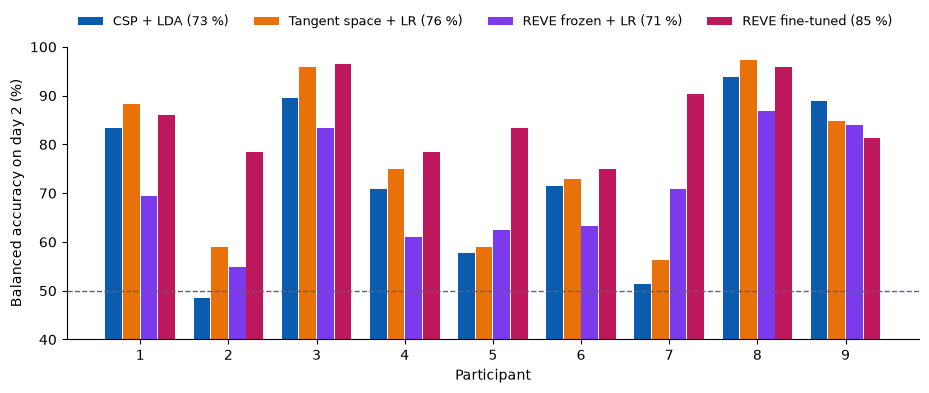

subject,1,2,3,4,5,6,7,8,9,mean
method,,,,,,,,,,
CSP + LDA,83.0,49.0,90.0,71.0,58.0,72.0,51.0,94.0,89.0,73.0
Tangent space + LR,88.0,59.0,96.0,75.0,59.0,73.0,56.0,97.0,85.0,76.0
REVE frozen + LR,69.0,55.0,83.0,61.0,62.0,63.0,71.0,87.0,84.0,71.0
REVE fine-tuned,86.0,78.0,97.0,78.0,83.0,75.0,90.0,96.0,81.0,85.0


In [13]:
# ---- The four decoders, participant by participant
earlier = [RESULTS_DIR / "classical.csv", RESULTS_DIR / "fm_frozen.csv"]
if not all(f.exists() for f in earlier):
    raise FileNotFoundError("Run 02_classical.ipynb and 03_fm_frozen.ipynb first: they save the scores of the other decoders.")
table = pd.concat(pd.read_csv(f) for f in earlier).pivot(index="method", columns="subject", values="balanced_accuracy")
table.loc["REVE fine-tuned"] = finetuned_scores
table = table.loc[list(COLORS), SUBJECTS]
table["mean"] = table.mean(axis=1)

fig, ax = plt.subplots(figsize=(11, 3.8))
for k, (name, color) in enumerate(COLORS.items()):
    ax.bar(np.arange(len(SUBJECTS)) + 0.2 * (k - 1.5), 100 * table.loc[name, SUBJECTS], width=0.19, color=color,
           label=f"{name} ({100 * table.loc[name, 'mean']:.0f} %)")
ax.axhline(50, color="#5B6472", lw=1, ls="--")
ax.set_xticks(range(len(SUBJECTS)), SUBJECTS)
ax.set_xlabel("Participant")
ax.set_ylabel("Balanced accuracy on day 2 (%)")
ax.set_ylim(40, 100)
ax.legend(loc="upper left", ncols=4, bbox_to_anchor=(0, 1.15), fontsize=9)
plt.show()
(100 * table).round(0)

The fine-tuned model reaches 85 % on day 2, against 76 % for tangent space + LR, 73 % for CSP + LDA and 71 % for the frozen model. The largest gains are for the participants the classical decoders could not decode: 2 (78 %), 5 (83 %) and 7 (90 %). For participants 1, 8 and 9 it is 1 to 8 points below the best classical decoder.

<div style="border-left:5px solid #E8710A; background:#FDF1E7; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#E8710A;">Watch out</b><br>This comparison is not on equal terms. The fine-tuned model learned from the day 1 of <b>nine</b> participants, 1,101 trials; the three other decoders learned from the day 1 of <b>one</b> participant, 144 trials. Notebook 3 saved what the other decoders reach when they too are trained on everyone's day 1. The next cell puts the four side by side.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The same training data for everyone

In [14]:
# ---- The four decoders when all of them are trained on everyone's day 1
pooled = pd.read_csv(RESULTS_DIR / "pooled.csv").pivot(index="method", columns="subject", values="balanced_accuracy")
pooled.loc["REVE fine-tuned"] = finetuned_scores
pooled = pooled.loc[list(COLORS), SUBJECTS]
pooled["mean"] = pooled.mean(axis=1)

both = pd.DataFrame({"trained on own day 1": table["mean"], "trained on everyone's day 1": pooled["mean"]})
both.loc["REVE fine-tuned", "trained on own day 1"] = np.nan         # part 6 fills this in
(100 * both).round(0)

,trained on own day 1,trained on everyone's day 1
method,,
CSP + LDA,73.0,71.0
Tangent space + LR,76.0,70.0
REVE frozen + LR,71.0,73.0
REVE fine-tuned,NaN,85.0


Trained on everyone's day 1, the classical decoders get worse (71 % and 70 %) and the frozen probe reaches 73 %. The fine-tuned model is 12 points above the best of them. More training data alone does not explain its score: the other decoders had the same data.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Save the scores

In [15]:
# ---- Save the scores for notebook 5
scores = pd.DataFrame({"method": "REVE fine-tuned", "subject": finetuned_scores.index,
                       "balanced_accuracy": finetuned_scores.to_numpy(), "auc": finetuned_auc.to_numpy(),
                       "seconds": history["seconds"].max() / len(SUBJECTS), "training_data": "everyone's day 1",
                       "training_labels": "100 %", "adapted_parameters": "all", "hardware": "GPU"})
scores.to_csv(RESULTS_DIR / "fm_finetuned.csv", index=False)
print("Saved", len(scores), "rows to", RESULTS_DIR / "fm_finetuned.csv")

Saved 9 rows to results/fm_finetuned.csv


## 5. What changed inside the model

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>After fine-tuning, the embeddings are organised by imagined hand instead of by participant.</div>

In notebook 3 the frozen embeddings formed one cloud per participant, with the two hands mixed. We draw the same picture before and after fine-tuning. The second panel uses the embeddings of the fine-tuned model, saved with the run.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> The embeddings before and after

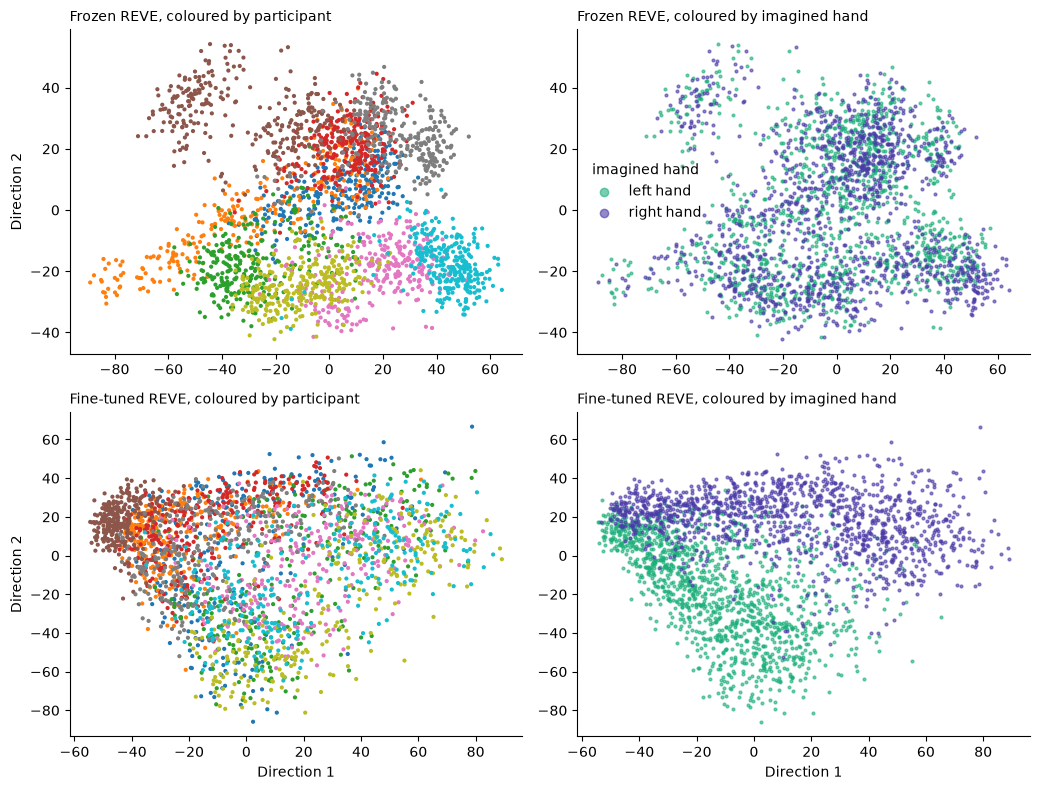

In [16]:
# ---- Every trial in the two main directions of the embeddings: frozen model, then fine-tuned model
cache = mf.load_embedding_cache(SUBJECTS)
frozen = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(cache["X"].reshape(len(cache["X"]), -1)))
after = mf.load_precomputed("embeddings")

fig, axes = plt.subplots(2, 2, figsize=(10.5, 8))
for row, plane, name in [(axes[0], frozen, "Frozen REVE"),
                         (axes[1], after[["direction_1", "direction_2"]].to_numpy(), "Fine-tuned REVE")]:
    row[0].scatter(plane[:, 0], plane[:, 1], c=subject, cmap="tab10", s=4)
    row[0].set_title(f"{name}, coloured by participant", loc="left", fontsize=10)
    for cls, color in HANDS.items():
        row[1].scatter(plane[y == cls, 0], plane[y == cls, 1], s=4, color=color, alpha=0.6, label=cls.replace("_", " "))
    row[1].set_title(f"{name}, coloured by imagined hand", loc="left", fontsize=10)
    row[0].set_ylabel("Direction 2")
for ax in axes[1]:
    ax.set_xlabel("Direction 1")
axes[0, 1].legend(title="imagined hand", markerscale=3)
plt.tight_layout()
plt.show()

The two rows show the same trials. In the frozen model (top) each participant forms a cloud and the hands are mixed. After fine-tuning (bottom) the participants overlap and the two hands separate along the second direction. Fine-tuning reorganised the embeddings around the question we asked: the largest differences between trials are now between hands, for all participants at once. This picture includes the day-1 trials the model learned from, so it shows what changed, and the scores of part 4 show how well it carries over to day 2.

## 6. One participant alone, and fewer labels

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>The gain depends on many labelled trials from several people. With one participant, or a tenth of the labels, it disappears.</div>

Two more saved runs with the same recipe show what the result depends on.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> One model per participant

Nine separate models, each fine-tuned on the day 1 of a single participant: the setting of notebooks 2 and 3.

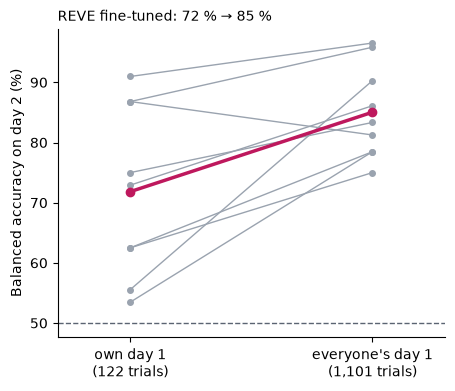

,trained on own day 1,trained on everyone's day 1
method,,
CSP + LDA,73.0,71.0
Tangent space + LR,76.0,70.0
REVE frozen + LR,71.0,73.0
REVE fine-tuned,72.0,85.0


In [17]:
# ---- Fine-tuned on one participant at a time, against fine-tuned on everyone
alone = day2_scores(saved_predictions[saved_predictions["run"].str.endswith("alone")])
both.loc["REVE fine-tuned", "trained on own day 1"] = alone.mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [100 * alone, 100 * finetuned_scores], color="#9AA3AF", lw=1, marker="o", ms=4)
ax.plot([0, 1], [100 * alone.mean(), 100 * finetuned_scores.mean()], color=COLORS["REVE fine-tuned"], lw=2.5, marker="o")
ax.axhline(50, color="#5B6472", lw=1, ls="--")
ax.set_xticks([0, 1], ["own day 1\n(122 trials)", "everyone's day 1\n(1,101 trials)"])
ax.set_xlim(-0.3, 1.3)
ax.set_ylabel("Balanced accuracy on day 2 (%)")
ax.set_title(f"REVE fine-tuned: {100 * alone.mean():.0f} % → {100 * finetuned_scores.mean():.0f} %", loc="left", fontsize=10)
plt.show()
(100 * both).round(0)

Fine-tuned on one participant at a time, REVE reaches 72 % on average, no better than the frozen probe (71 %) and below tangent space + LR (76 %). With 122 trials, 69 million weights learn the training trials by heart. The 85 % comes from fine-tuning on several people together.

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> With 10 % of the labels

One model for everyone again, but with 14 trials per participant instead of 122: 126 labelled trials in total. With ten times fewer trials a pass has ten times fewer steps, so this run makes more passes (10 for the head, then 40), and it was repeated with two seeds. Notebook 3 saved the curves of the three other decoders, each trained on 14 trials of one participant.

In [18]:
# ---- The four decoders with 10 % of the labels
few_runs = saved_predictions[saved_predictions["run"] == "all participants, 10 % of the labels"]
few = few_runs.groupby("seed").apply(day2_scores, include_groups=False).mean()        # mean of the two seeds, per participant
curve = pd.read_csv(RESULTS_DIR / "label_curve.csv", index_col="training_trials")
labels = pd.DataFrame({"10 % of day 1": curve.loc[14], "all of day 1": curve.loc[144]})
labels.loc["REVE fine-tuned"] = [few.mean(), finetuned_scores.mean()]
few.rename("balanced_accuracy").reset_index().assign(
    method="REVE fine-tuned", training_data="everyone's day 1", training_labels="10 %", adapted_parameters="all",
    hardware="GPU").to_csv(RESULTS_DIR / "fm_finetuned_10pct.csv", index=False)       # for notebook 5
(100 * labels.loc[list(COLORS)]).round(0)

,10 % of day 1,all of day 1
CSP + LDA,66.0,73.0
Tangent space + LR,69.0,76.0
REVE frozen + LR,58.0,71.0
REVE fine-tuned,52.0,85.0


With 14 trials per participant the fine-tuned model is at 52 %, at chance, with both seeds, and below every other decoder (tangent space + LR keeps 69 %). On this dataset fine-tuning needs labels: it is the best decoder with all of day 1 and the worst with a tenth of it. The idea that a pretrained model needs few labels does not hold here, for the probe or for fine-tuning.

## 7. What it costs

<div style="border-left:5px solid #0B2545; background:#E8EEF6; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#0B2545;">In short</b><br>Fine-tuning costs minutes on a GPU. The classical decoders cost seconds on a laptop.</div>

### <span style="background:#0B5CAD; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 1</span> Time and hardware

In [19]:
# ---- Training time of each decoder for the 9 participants
seconds = pd.concat(pd.read_csv(f) for f in earlier).groupby("method")["seconds"].sum()
cost = pd.DataFrame({
    "weights that learn": ["a few hundred", "a few hundred", "about 11,000 (the probe)", "69 million"],
    "training time, 9 participants": [f"{seconds['CSP + LDA']:.0f} s", f"{seconds['Tangent space + LR']:.0f} s",
                                      f"{seconds['REVE frozen + LR']:.1f} s, after computing the embeddings",
                                      f"{history['seconds'].max() / 60:.0f} min"],
    "hardware": ["laptop", "laptop", "laptop", "GPU"],
    "balanced accuracy on day 2 (%)": (100 * table["mean"]).round(0).astype(int).to_numpy(),
}, index=list(COLORS))
cost

,weights that learn,"training time, 9 participants",hardware,balanced accuracy on day 2 (%)
CSP + LDA,a few hundred,1 s,laptop,73
Tangent space + LR,a few hundred,2 s,laptop,76
REVE frozen + LR,"about 11,000 (the probe)","0.4 s, after computing the embeddings",laptop,71
REVE fine-tuned,69 million,5 min,GPU,85


The classical decoders train in about 2 seconds for the 9 participants on a laptop. Fine-tuning took about 5 minutes on a GPU and changes 69 million weights, for 9 more points than the best classical decoder. Whether 9 points are worth a GPU depends on the use; notebook 5 looks at how sure we can be of those 9 points.

## 8. Go further (optional)

### <span style="background:#E8710A; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 2</span> Who gains from fine-tuning?

For each participant, compute the gain of the fine-tuned model over the better of the two classical decoders. Who gains most? Compare with what notebook 1 showed for these participants.

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>table</code> has one row per decoder and one column per participant. <code>table.loc[[&quot;CSP + LDA&quot;, &quot;Tangent space + LR&quot;], SUBJECTS]</code> keeps the two classical rows; <code>.max()</code> then gives the higher score of each column.</div>

In [20]:
# ---- Exercise: gain of the fine-tuned model over the best classical decoder, per participant
best_classical = ...                                 # <--- for each participant, the higher of the two classical scores

if best_classical is not ...:                        # runs once the line above is completed
    gain = (100 * (table.loc["REVE fine-tuned", SUBJECTS] - best_classical)).round(0)
    print("Gain in points, by participant:")
    print(gain.astype(int).to_string())

In [21]:
#@title Solution (try first)
# ---- Gain of the fine-tuned model over the best classical decoder, per participant
best_classical = table.loc[["CSP + LDA", "Tangent space + LR"], SUBJECTS].max()
gain = (100 * (table.loc["REVE fine-tuned", SUBJECTS] - best_classical)).round(0)
pd.DataFrame({"best classical (%)": (100 * best_classical).round(0), "fine-tuned (%)": (100 * table.loc["REVE fine-tuned", SUBJECTS]).round(0),
              "gain (points)": gain}).T
# The gains are largest for participants 7 (+34), 5 (+24) and 2 (+19): the ones with no difference between sides in
# notebook 1. For participants the classical decoders already decode well, fine-tuning changes little (9 loses 8 points).

subject,1,2,3,4,5,6,7,8,9
best classical (%),88.0,59.0,96.0,75.0,59.0,73.0,56.0,97.0,89.0
fine-tuned (%),86.0,78.0,97.0,78.0,83.0,75.0,90.0,96.0,81.0
gain (points),-2.0,19.0,1.0,3.0,24.0,2.0,34.0,-1.0,-8.0


### <span style="background:#7C3AED; color:#FFFFFF; border-radius:12px; padding:2px 10px; font-size:0.72em; vertical-align:middle;">Type 3</span> Fine-tune it yourself (GPU)

With a GPU, fine-tune REVE on one participant of your choice and compare with the saved run for that participant. Then change one thing in the recipe, for example the learning rate or the number of passes. Which set of trials should you look at to decide whether the change helped?

<div style="border-left:5px solid #7C3AED; background:#F5F0FF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#7C3AED;">Hints</b><br><code>mf.finetune_reve(X[rows_fit], y[rows_fit], X[rows_held_out], y[rows_held_out], device=DEVICE, **RECIPE)</code> returns the model and its history. <code>mf.predict_proba(model, X[rows])</code> gives the probabilities. A participant alone takes about one minute on a GPU.</div>

In [22]:
# ---- Type 3: fine-tune on one participant, then change the recipe (optional, GPU)

In [23]:
#@title Solution (try first)
# ---- Fine-tune on one participant with the recipe of the saved runs
PARTICIPANT = 9
if RUN_FINETUNE:
    own = np.flatnonzero(train & (subject == PARTICIPANT))
    own_fit, own_held_out = train_test_split(own, test_size=0.15, stratify=y[own], random_state=0)
    own_model, own_history = mf.finetune_reve(X[own_fit], y[own_fit], X[own_held_out], y[own_held_out], device=DEVICE,
                                              **{**RECIPE, "batch_size": 16})
    rows = test & (subject == PARTICIPANT)
    answers = np.array(mf.CLASSES)[mf.predict_proba(own_model, X[rows]).argmax(axis=1)]
    print(f"Participant {PARTICIPANT}, this run: {100 * balanced_accuracy_score(y[rows], answers):.0f} % on day 2")
print(f"Participant {PARTICIPANT}, saved run: {100 * alone[PARTICIPANT]:.0f} % on day 2")
# To judge a change of recipe, look at the held-out trials of day 1, never at day 2: choosing the recipe that
# scores best on day 2 is the leakage of notebook 2. Repeat a run with another seed before believing a difference.

Participant 9, saved run: 87 % on day 2


## 9. Summary

| Step | Function | Package |
|---|---|---|
| Model with a head | `mf.load_reve` (`REVE.from_pretrained`) | Braindecode |
| Freeze weights | `p.requires_grad = False` | PyTorch |
| One learning step | `cross_entropy`, `loss.backward()`, `optimizer.step()` | PyTorch |
| Full run in two stages | `mf.finetune_reve` | tutorial package |
| Probabilities for new trials | `mf.predict_proba` | tutorial package |
| Saved runs | `mf.load_precomputed` | tutorial package |
| Held-out trials | `train_test_split(..., stratify=...)` | scikit-learn |

<div style="border-left:5px solid #15803D; background:#ECF8EF; color:#1F2937; padding:10px 16px; border-radius:6px; margin:8px 0;"><b style="color:#15803D;">Take-aways</b><br><ul style='margin:0;'><li>A network learns by repeating one step: compute the loss on a batch, get its gradient, move the weights a little.</li><li>Fine-tuned on the day 1 of all participants, REVE reaches 85 % on day 2, against 76 % for the best classical decoder.</li><li>The gain comes from the participants the classical decoders could not decode, and from training on several people at once.</li><li>Fine-tuned on one participant, or with a tenth of the labels, it does no better than the simpler decoders, or worse.</li><li>Runs differ with the random seed: 84.6 to 85.2 % for our recipe, and one failure in four for a simpler one. Held-out trials of day 1 show a failed run without touching day 2.</li><li>It costs minutes on a GPU, against seconds on a laptop.</li></ul></div>

**Next**: `05_compare.ipynb`.

<details><summary>References</summary>

- El Ouahidi, Y., Lys, J., Thölke, P., Farrugia, N., Pasdeloup, B., Gripon, V., Jerbi, K., & Lioi, G. (2025). REVE: A foundation model for EEG, adapting to any setup with large-scale pretraining on 25,000 subjects. *Advances in Neural Information Processing Systems 38*. https://arxiv.org/abs/2510.21585
- Kumar, A., Raghunathan, A., Jones, R., Ma, T., & Liang, P. (2022). Fine-tuning can distort pretrained features and underperform out-of-distribution. *International Conference on Learning Representations*. https://arxiv.org/abs/2202.10054
- Loshchilov, I., & Hutter, F. (2019). Decoupled weight decay regularization. *International Conference on Learning Representations*. https://arxiv.org/abs/1711.05101
- Paszke, A., Gross, S., Massa, F., Lerer, A., Bradbury, J., Chanan, G., ... Chintala, S. (2019). PyTorch: An imperative style, high-performance deep learning library. *Advances in Neural Information Processing Systems 32*. https://arxiv.org/abs/1912.01703
- Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. *Nature, 323*, 533-536. https://doi.org/10.1038/323533a0
</details>